# 01 Smoke Test

Colab validation notebook for the first real D1 run.

- Repo remains the source of truth.
- Notebook bootstraps Colab, installs GroundingDINO and SAM2 in a Colab-friendly way, fetches smoke assets, and calls the repository CLI.
- Primary video path is the official SAM2 video predictor.


In [1]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
REPO_URL = 'https://github.com/ChiCoTheLaAnh/ProjectFinalCS415.git'
REPO_DIR = '/content/ProjectFinalCS415'

!rm -rf "$REPO_DIR"
!git clone "$REPO_URL" "$REPO_DIR"


Cloning into '/content/ProjectFinalCS415'...
remote: Enumerating objects: 99, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 99 (delta 36), reused 89 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (99/99), 29.93 KiB | 14.96 MiB/s, done.
Resolving deltas: 100% (36/36), done.


In [3]:
%cd /content/ProjectFinalCS415
!bash setup_colab.sh


/content/ProjectFinalCS415
[setup] upgrading pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 68.0 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
[setup] installing pinned base dependencies
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 111.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 152.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.

In [4]:
%cd /content
!pip install -U ninja
!pip install torch==2.5.1 torchvision==0.20.1 --index-url https://download.pytorch.org/whl/cu124
!pip install transformers==4.46.3 accelerate==1.0.1 huggingface_hub==0.26.2 supervision==0.25.1


/content
Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.2/908.2 MB 38.5 MB/s  0:00:09
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 178.3 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 201.3 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 33.2 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 200.6 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 44.3 MB/s  0:00:07
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 63.8 MB/s  0:00:04
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 81.8 MB/s  0:00:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 163.2 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 148.3 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 76.1 MB/s  0:00:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7

In [5]:
%cd /content
!rm -rf GroundingDINO
!git clone https://github.com/IDEA-Research/GroundingDINO.git
%cd /content/GroundingDINO
!git checkout v0.1.0-alpha2
!export CUDA_HOME=/usr/local/cuda && export FORCE_CUDA=1 && pip install --no-build-isolation -e .


/content
Cloning into 'GroundingDINO'...
remote: Enumerating objects: 463, done.
remote: Total 463 (delta 0), reused 0 (delta 0), pack-reused 463 (from 1)
Receiving objects: 100% (463/463), 12.91 MiB | 7.37 MiB/s, done.
Resolving deltas: 100% (220/220), done.
/content/GroundingDINO
Note: switching to 'v0.1.0-alpha2'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 22292c4 add grounding dino with stable diffusion for image editing (#20)
Obtaining file:///content/GroundingDINO
  Checking if build backend supports

In [6]:
%cd /content
!rm -rf sam2
!git clone https://github.com/facebookresearch/sam2.git
%cd /content/sam2
!git checkout 2b90b9f5ceec907a1c18123530e92e794ad901a4
!pip uninstall -y SAM-2 sam2 || true
!export CUDA_HOME=/usr/local/cuda && pip install --no-build-isolation -e .


/content
Cloning into 'sam2'...
remote: Enumerating objects: 1091, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 1091 (delta 7), reused 4 (delta 4), pack-reused 1080 (from 4)
Receiving objects: 100% (1091/1091), 128.27 MiB | 16.27 MiB/s, done.
Resolving deltas: 100% (390/390), done.
/content/sam2
Note: switching to '2b90b9f5ceec907a1c18123530e92e794ad901a4'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 2b90b9f remove `.pin_memory()` in `obj_p

In [8]:
%cd /content
!rm -rf GroundingDINO
!git clone https://github.com/IDEA-Research/GroundingDINO.git
%cd /content/GroundingDINO
!git checkout v0.1.0-alpha2
!pip install -U ninja
!export CUDA_HOME=/usr/local/cuda && export FORCE_CUDA=1 && pip install --no-build-isolation -e .


/content
Cloning into 'GroundingDINO'...
remote: Enumerating objects: 463, done.
remote: Total 463 (delta 0), reused 0 (delta 0), pack-reused 463 (from 1)
Receiving objects: 100% (463/463), 12.91 MiB | 8.43 MiB/s, done.
Resolving deltas: 100% (220/220), done.
/content/GroundingDINO
Note: switching to 'v0.1.0-alpha2'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 22292c4 add grounding dino with stable diffusion for image editing (#20)
Obtaining file:///content/GroundingDINO
  Checking if build backend supports

In [9]:
import groundingdino
print(groundingdino.__file__)


/content/GroundingDINO/groundingdino/__init__.py


In [10]:
import shutil
import subprocess
import sys
import torch

print('Python:', sys.version)
print('Torch:', torch.__version__)
print('Torch CUDA runtime:', torch.version.cuda)
cuda_available = torch.cuda.is_available()
print('CUDA available:', cuda_available)

nvidia_smi = shutil.which('nvidia-smi')
if nvidia_smi is None:
    print('GPU runtime not attached: nvidia-smi not found.')
else:
    gpu_name = subprocess.run(
        [nvidia_smi, '--query-gpu=name', '--format=csv,noheader'],
        capture_output=True,
        text=True,
        check=True,
    ).stdout.strip()
    print('GPU:', gpu_name)

if not cuda_available:
    raise RuntimeError('Colab GPU runtime is not attached. Go to Runtime > Change runtime type > GPU, restart the session, then rerun from the top.')

import groundingdino
import sam2

print('GroundingDINO import OK:', groundingdino.__file__)
print('SAM2 import OK:', sam2.__file__)


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch: 2.5.1+cu124
Torch CUDA runtime: 12.4
CUDA available: True
GPU: Tesla T4
GroundingDINO import OK: /content/GroundingDINO/groundingdino/__init__.py
SAM2 import OK: None


In [11]:
from pathlib import Path
from urllib.request import urlretrieve

DRIVE_ROOT = Path('/content/drive/MyDrive/cv-final-project')
CHECKPOINT_DIR = DRIVE_ROOT / 'checkpoints'
INPUT_DIR = DRIVE_ROOT / 'inputs'
OUTPUT_ROOT = DRIVE_ROOT / 'results' / 'smoke_test'
GROUNDING_CKPT_URL = 'https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth'
SAM2_CKPT_URL = 'https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt'
GROUNDING_CKPT = CHECKPOINT_DIR / 'groundingdino_swint_ogc.pth'
SAM2_CKPT = CHECKPOINT_DIR / 'sam2.1_hiera_small.pt'

DEFAULT_IMAGE_URL = 'https://raw.githubusercontent.com/IDEA-Research/GroundingDINO/main/.asset/cat_dog.jpeg'
DEFAULT_VIDEO_URL = 'https://raw.githubusercontent.com/IDEA-Research/Grounded-SAM-2/main/assets/hippopotamus.mp4'
DEFAULT_IMAGE_PATH = INPUT_DIR / 'groundingdino_cat_dog.jpeg'
DEFAULT_VIDEO_PATH = INPUT_DIR / 'grounded_sam2_hippopotamus.mp4'

IMAGE_PROMPT = 'dog'
VIDEO_PROMPT = 'hippopotamus'
MAX_FRAMES = 10
DEVICE = 'cuda'

for path in (CHECKPOINT_DIR, INPUT_DIR, OUTPUT_ROOT):
    path.mkdir(parents=True, exist_ok=True)

def download_if_missing(url: str, path: Path) -> None:
    if not path.exists():
        print(f'Downloading {path.name}...')
        urlretrieve(url, path)
    else:
        print(f'Already exists: {path}')

download_if_missing(GROUNDING_CKPT_URL, GROUNDING_CKPT)
download_if_missing(SAM2_CKPT_URL, SAM2_CKPT)
download_if_missing(DEFAULT_IMAGE_URL, DEFAULT_IMAGE_PATH)
download_if_missing(DEFAULT_VIDEO_URL, DEFAULT_VIDEO_PATH)

INPUT_IMAGE = str(DEFAULT_IMAGE_PATH)
INPUT_VIDEO = str(DEFAULT_VIDEO_PATH)
GROUNDING_CKPT = str(GROUNDING_CKPT)
SAM2_CKPT = str(SAM2_CKPT)

print('Image prompt:', IMAGE_PROMPT)
print('Video prompt:', VIDEO_PROMPT)
print('Image path:', INPUT_IMAGE)
print('Video path:', INPUT_VIDEO)
print('Grounding checkpoint:', GROUNDING_CKPT)
print('SAM2 checkpoint:', SAM2_CKPT)


Already exists: /content/drive/MyDrive/cv-final-project/checkpoints/groundingdino_swint_ogc.pth
Already exists: /content/drive/MyDrive/cv-final-project/checkpoints/sam2.1_hiera_small.pt
Already exists: /content/drive/MyDrive/cv-final-project/inputs/groundingdino_cat_dog.jpeg
Already exists: /content/drive/MyDrive/cv-final-project/inputs/grounded_sam2_hippopotamus.mp4
Image prompt: dog
Video prompt: hippopotamus
Image path: /content/drive/MyDrive/cv-final-project/inputs/groundingdino_cat_dog.jpeg
Video path: /content/drive/MyDrive/cv-final-project/inputs/grounded_sam2_hippopotamus.mp4
Grounding checkpoint: /content/drive/MyDrive/cv-final-project/checkpoints/groundingdino_swint_ogc.pth
SAM2 checkpoint: /content/drive/MyDrive/cv-final-project/checkpoints/sam2.1_hiera_small.pt


In [12]:
for required_path in (Path(GROUNDING_CKPT), Path(SAM2_CKPT)):
    if not required_path.exists():
        raise FileNotFoundError(f'Missing checkpoint: {required_path}')
    print(required_path, required_path.stat().st_size, 'bytes')


/content/drive/MyDrive/cv-final-project/checkpoints/groundingdino_swint_ogc.pth 693997677 bytes
/content/drive/MyDrive/cv-final-project/checkpoints/sam2.1_hiera_small.pt 184416285 bytes


In [13]:
%cd /content/ProjectFinalCS415
import shutil
import subprocess

IMAGE_OUTPUT = str(OUTPUT_ROOT / 'image')
shutil.rmtree(IMAGE_OUTPUT, ignore_errors=True)

cmd = [
    'python3', 'scripts/run_custom_video.py',
    '--config', 'configs/base.yaml',
    '--input_video', INPUT_IMAGE,
    '--prompt', IMAGE_PROMPT,
    '--output_dir', IMAGE_OUTPUT,
    '--grounding_ckpt', GROUNDING_CKPT,
    '--sam2_ckpt', SAM2_CKPT,
    '--device', DEVICE,
    '--max_frames', '1',
]
print('Running:', ' '.join(cmd))
subprocess.run(cmd, check=True)


/content/ProjectFinalCS415
Running: python3 scripts/run_custom_video.py --config configs/base.yaml --input_video /content/drive/MyDrive/cv-final-project/inputs/groundingdino_cat_dog.jpeg --prompt dog --output_dir /content/drive/MyDrive/cv-final-project/results/smoke_test/image --grounding_ckpt /content/drive/MyDrive/cv-final-project/checkpoints/groundingdino_swint_ogc.pth --sam2_ckpt /content/drive/MyDrive/cv-final-project/checkpoints/sam2.1_hiera_small.pt --device cuda --max_frames 1


CompletedProcess(args=['python3', 'scripts/run_custom_video.py', '--config', 'configs/base.yaml', '--input_video', '/content/drive/MyDrive/cv-final-project/inputs/groundingdino_cat_dog.jpeg', '--prompt', 'dog', '--output_dir', '/content/drive/MyDrive/cv-final-project/results/smoke_test/image', '--grounding_ckpt', '/content/drive/MyDrive/cv-final-project/checkpoints/groundingdino_swint_ogc.pth', '--sam2_ckpt', '/content/drive/MyDrive/cv-final-project/checkpoints/sam2.1_hiera_small.pt', '--device', 'cuda', '--max_frames', '1'], returncode=0)

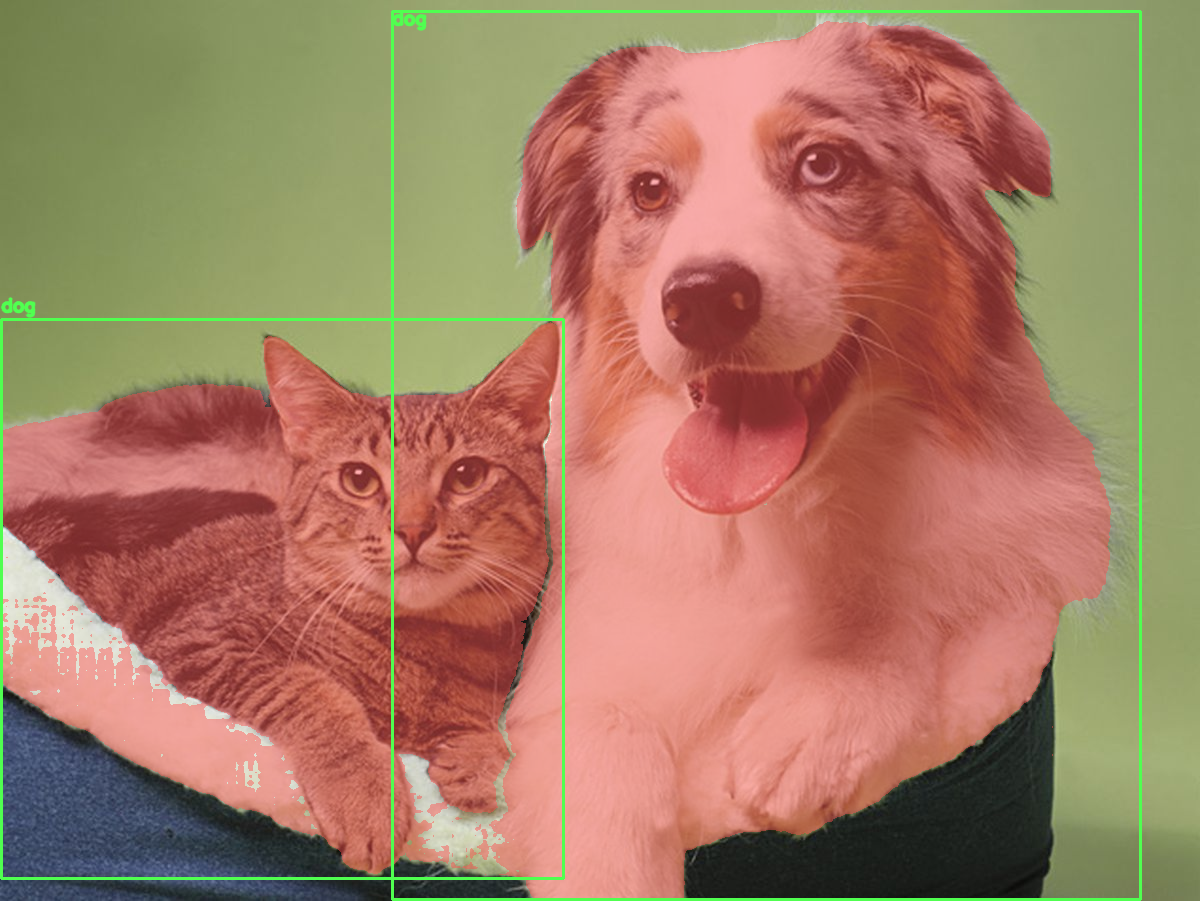

{
  "artifacts": {
    "image_overlay": "/content/drive/MyDrive/cv-final-project/results/smoke_test/image/smoke_image_overlay.png"
  },
  "input_path": "/content/drive/MyDrive/cv-final-project/inputs/groundingdino_cat_dog.jpeg",
  "input_type": "image",
  "model_stack": "grounding_dino+sam2",
  "num_frames": 1,
  "prompt": "dog",
  "runtime_sec": 56.122
}


In [14]:
import json
from IPython.display import Image, display

image_overlay = Path(IMAGE_OUTPUT) / 'smoke_image_overlay.png'
image_summary_path = Path(IMAGE_OUTPUT) / 'run_summary.json'

if not image_overlay.exists():
    raise FileNotFoundError(f'Missing image overlay: {image_overlay}')
if not image_summary_path.exists():
    raise FileNotFoundError(f'Missing image summary: {image_summary_path}')

display(Image(filename=str(image_overlay)))
with image_summary_path.open('r', encoding='utf-8') as handle:
    image_summary = json.load(handle)
for required_field in ('model_stack', 'runtime_sec', 'artifacts'):
    if required_field not in image_summary:
        raise KeyError(f'Missing required image summary field: {required_field}')
print(json.dumps(image_summary, indent=2))


In [15]:
%cd /content/ProjectFinalCS415
import shutil
import subprocess

VIDEO_OUTPUT = str(OUTPUT_ROOT / 'video')
shutil.rmtree(VIDEO_OUTPUT, ignore_errors=True)

cmd = [
    'python3', 'scripts/run_custom_video.py',
    '--config', 'configs/base.yaml',
    '--input_video', INPUT_VIDEO,
    '--prompt', VIDEO_PROMPT,
    '--output_dir', VIDEO_OUTPUT,
    '--grounding_ckpt', GROUNDING_CKPT,
    '--sam2_ckpt', SAM2_CKPT,
    '--device', DEVICE,
    '--max_frames', str(MAX_FRAMES),
]
print('Running:', ' '.join(cmd))
subprocess.run(cmd, check=True)


/content/ProjectFinalCS415
Running: python3 scripts/run_custom_video.py --config configs/base.yaml --input_video /content/drive/MyDrive/cv-final-project/inputs/grounded_sam2_hippopotamus.mp4 --prompt hippopotamus --output_dir /content/drive/MyDrive/cv-final-project/results/smoke_test/video --grounding_ckpt /content/drive/MyDrive/cv-final-project/checkpoints/groundingdino_swint_ogc.pth --sam2_ckpt /content/drive/MyDrive/cv-final-project/checkpoints/sam2.1_hiera_small.pt --device cuda --max_frames 10


CompletedProcess(args=['python3', 'scripts/run_custom_video.py', '--config', 'configs/base.yaml', '--input_video', '/content/drive/MyDrive/cv-final-project/inputs/grounded_sam2_hippopotamus.mp4', '--prompt', 'hippopotamus', '--output_dir', '/content/drive/MyDrive/cv-final-project/results/smoke_test/video', '--grounding_ckpt', '/content/drive/MyDrive/cv-final-project/checkpoints/groundingdino_swint_ogc.pth', '--sam2_ckpt', '/content/drive/MyDrive/cv-final-project/checkpoints/sam2.1_hiera_small.pt', '--device', 'cuda', '--max_frames', '10'], returncode=0)

In [16]:
import json
from IPython.display import Video, display

video_overlay = Path(VIDEO_OUTPUT) / 'smoke_video_overlay.mp4'
video_summary_path = Path(VIDEO_OUTPUT) / 'run_summary.json'

if not video_overlay.exists():
    raise FileNotFoundError(f'Missing video overlay: {video_overlay}')
if not video_summary_path.exists():
    raise FileNotFoundError(f'Missing video summary: {video_summary_path}')

display(Video(str(video_overlay), embed=True))
with video_summary_path.open('r', encoding='utf-8') as handle:
    video_summary = json.load(handle)
for required_field in ('model_stack', 'runtime_sec', 'artifacts'):
    if required_field not in video_summary:
        raise KeyError(f'Missing required video summary field: {required_field}')
print(json.dumps(video_summary, indent=2))
print('video_mode:', video_summary['artifacts'].get('video_mode'))
if 'fallback_reason' in video_summary['artifacts']:
    print('fallback_reason:', video_summary['artifacts']['fallback_reason'])


{
  "artifacts": {
    "fallback_reason": "can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.",
    "video_mode": "frame_by_frame_fallback",
    "video_overlay": "/content/drive/MyDrive/cv-final-project/results/smoke_test/video/smoke_video_overlay.mp4"
  },
  "input_path": "/content/drive/MyDrive/cv-final-project/inputs/grounded_sam2_hippopotamus.mp4",
  "input_type": "video",
  "model_stack": "grounding_dino+sam2",
  "num_frames": 10,
  "prompt": "hippopotamus",
  "runtime_sec": 30.567
}
video_mode: frame_by_frame_fallback
fallback_reason: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.
